In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [19]:
# Load Libraries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
# Load Data

# Load dataset
data = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Display shapes
print("Data Shape:", data.shape)

# Preview
data.head()

Data Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Missing Values ---
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_55/2107331686.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


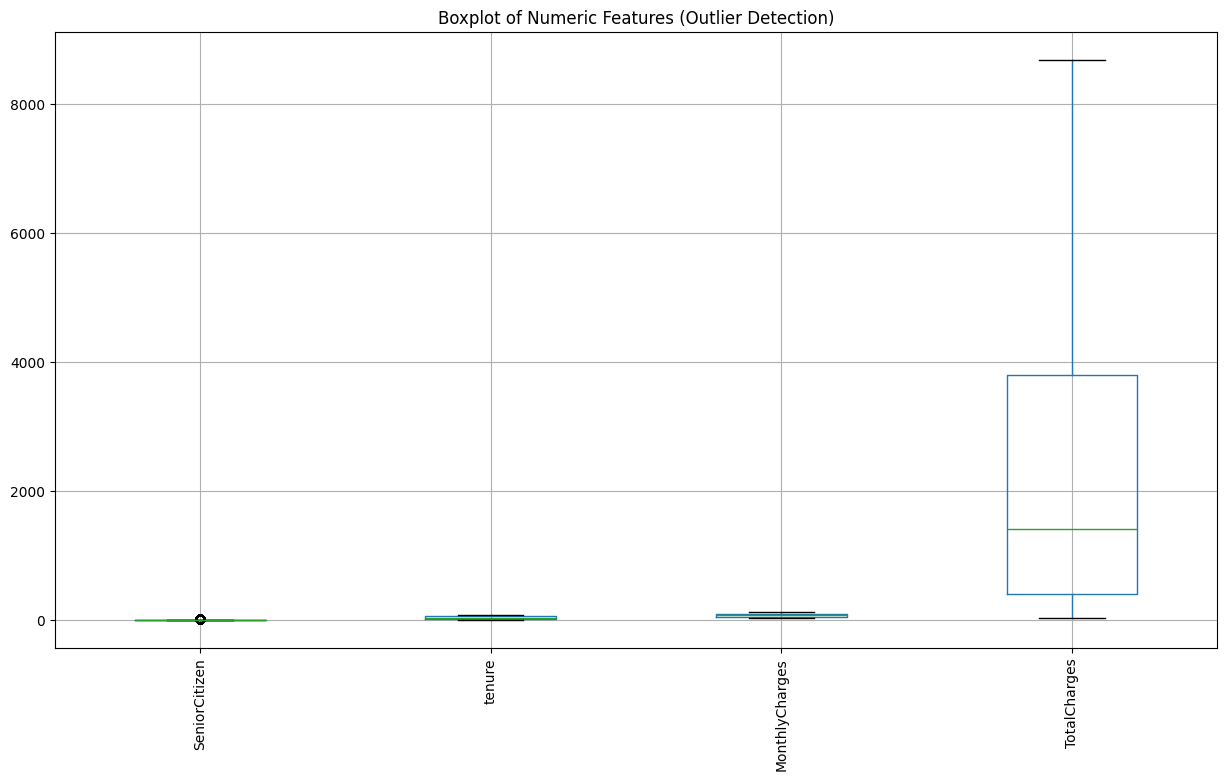

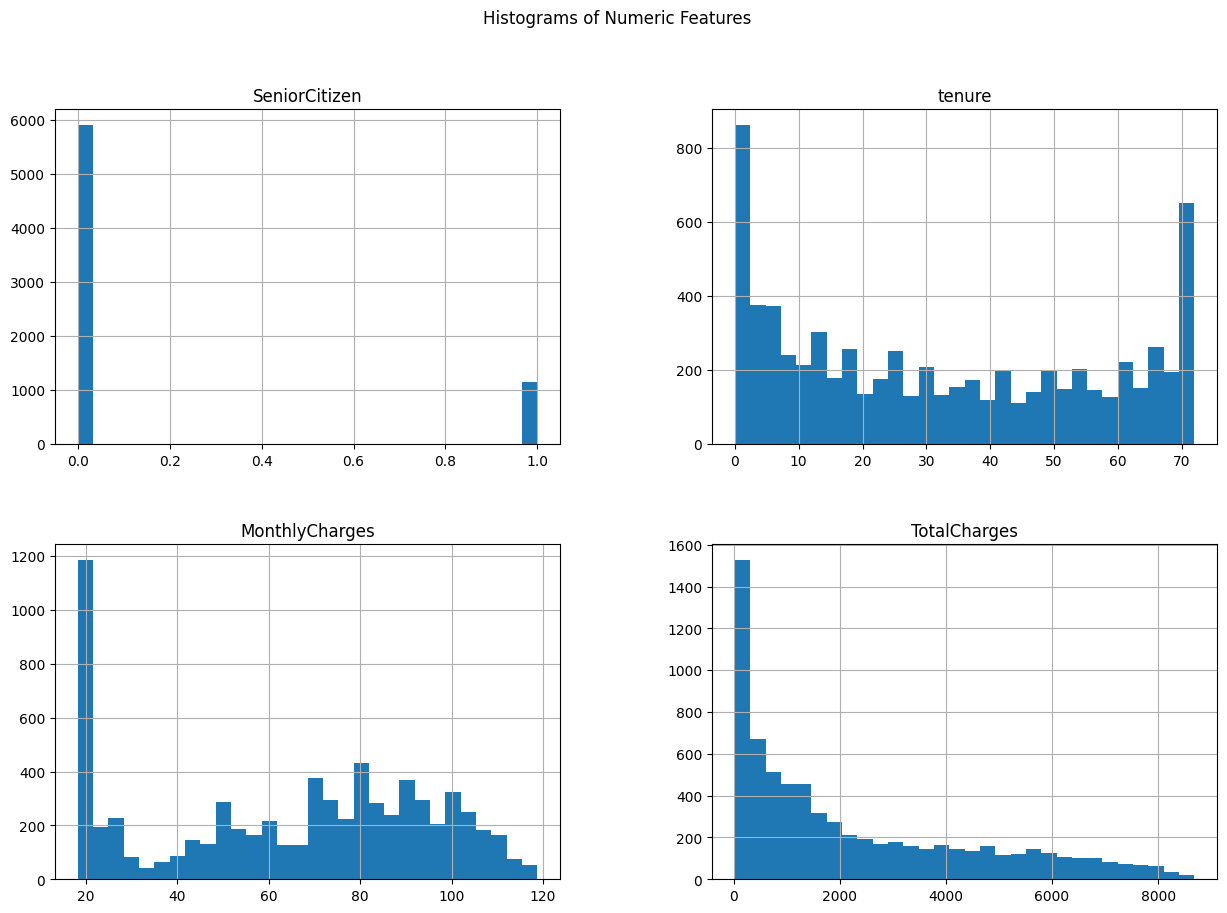

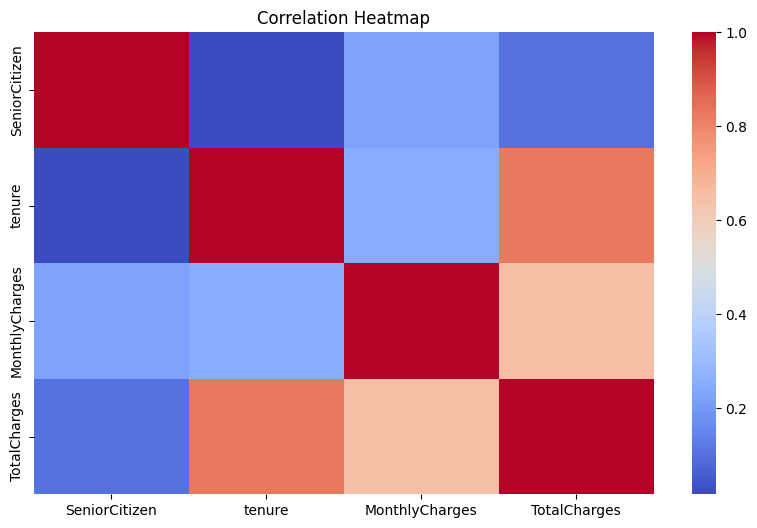

Outliers removed. Remaining rows: 5901
After removing outliers:


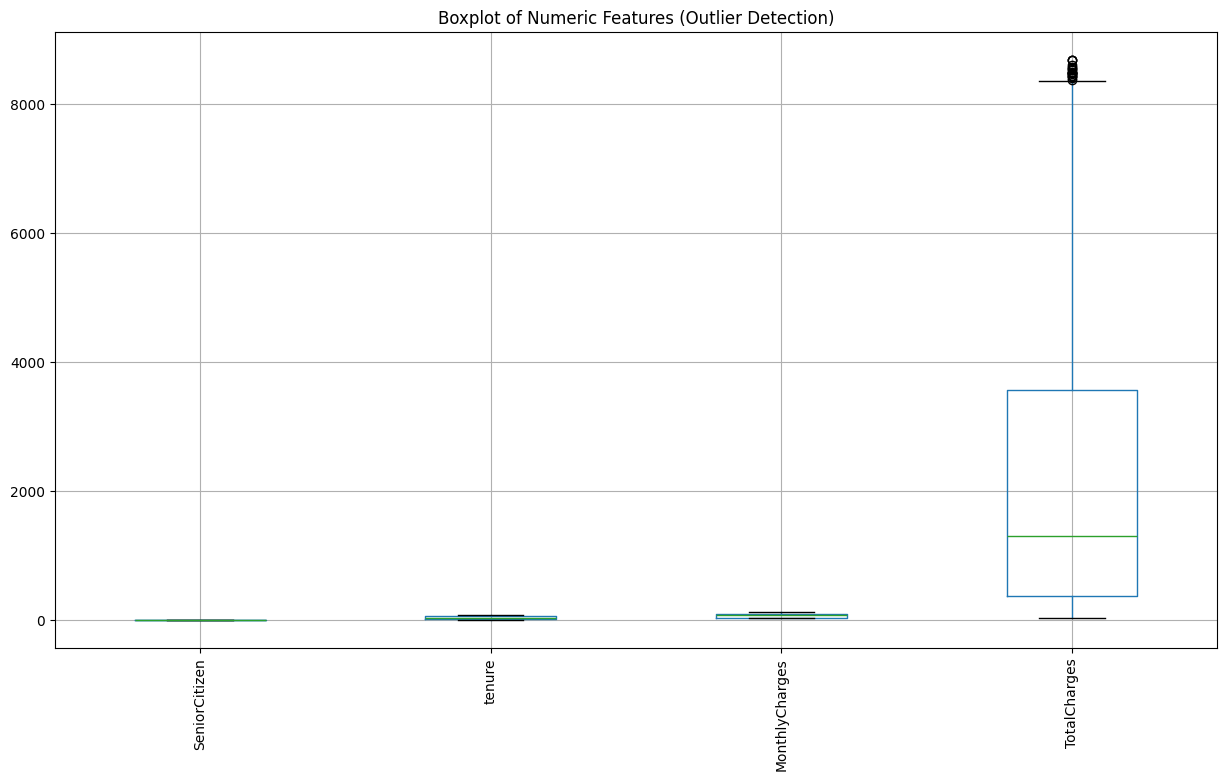

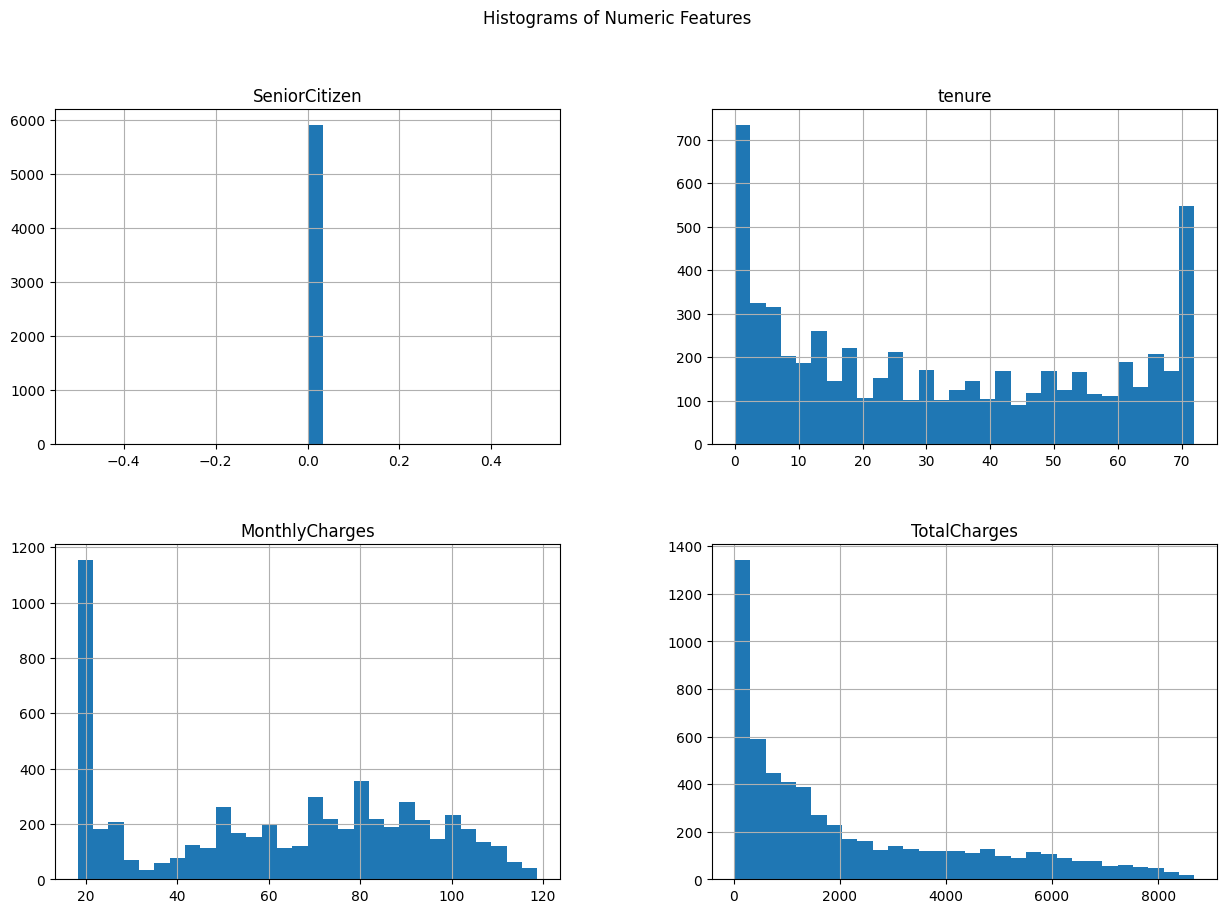

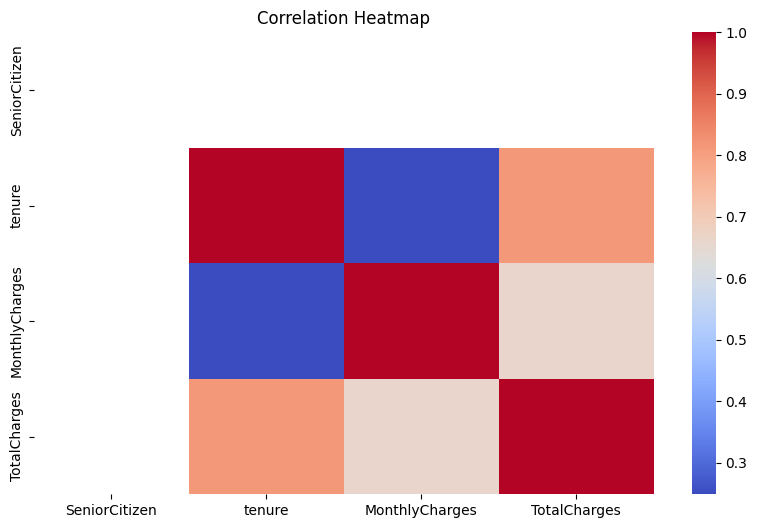

Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,Yes,No,0.013889,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.115423,0.001275,No
1,5575-GNVDE,Male,0.0,No,No,0.472222,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,0.385075,0.215867,No
2,3668-QPYBK,Male,0.0,No,No,0.027778,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,0.354229,0.010310,Yes
3,7795-CFOCW,Male,0.0,No,No,0.625000,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),0.239303,0.210241,No
4,9237-HQITU,Female,0.0,No,No,0.027778,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,0.521891,0.015330,Yes


In [21]:
# Cleaning process

def data_overview(df):
    # Count missing values
    missing = df.isnull().sum()
    print("\n--- Missing Values ---")
    print(missing)

    if(missing.sum() > 0):
        # Filter columns with missing values
        missing = missing[missing > 0].sort_values(ascending=False)

        # Plot bar chart
        plt.figure(figsize=(12,6))
        missing.plot(kind='bar')

        plt.title('Missing Values per Column')
        plt.xlabel('Features')
        plt.ylabel('Number of Missing Values')

        plt.show()
        
    print("\n--- Duplicate Rows ---")
    print(df.duplicated().sum().sum())

    return df

# =========================
# Handle Missing Values
# =========================
def handle_missing_values(df):

    # 1. Replace common fake missing values with actual NaN
    df = df.replace(
    ["NA", "N/A", "null", "?", "", "None", "nan", "NaN", " "],
    np.nan)
    

    # 2. Drop columns with more than 50% missing values
    threshold = len(df) * 0.5
    df = df.dropna(thresh=threshold, axis=1)

    # 3. Attempt to convert columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    # Identify numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    # 4. Fill missing values in numeric columns with mean
    df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # 5. Fill missing values in categorical columns
    for col in cat_cols:
        if df[col].mode().empty:
            # If no mode exists (all values are NaN), fill with placeholder
            df.loc[:, col] = df[col].fillna("Unknown")
        else:
            # Fill with most frequent value
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    
    # 7. Final check: drop any remaining missing values
    df = df.dropna()

    # Print remaining missing values (should be zero)
    print("Remaining missing values:", df.isnull().sum().sum())

    return df

# =========================
# Remove Duplicates
# =========================
def remove_duplicates(df):
    df = df.drop_duplicates()
    print("Duplicates removed.")
    return df


# =========================
# Fix Data Types
# =========================
def fix_data_types(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    print("Data types fixed.")
    return df


# =========================
# Handle Outliers (IQR)
# =========================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    mask = pd.Series(True, index=df.index)

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask &= df[col].between(lower_bound, upper_bound)

    df_cleaned = df[mask]

    print(f"Outliers removed. Remaining rows: {len(df_cleaned)}")
    return df_cleaned


def visualize_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    # 1. Boxplot
    plt.figure(figsize=(15, 8))
    df[num_cols].boxplot(rot=90)
    plt.title("Boxplot of Numeric Features (Outlier Detection)")
    plt.show()

    # 2. Histogram
    df[num_cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle("Histograms of Numeric Features")
    plt.show()

    # 3. Heatmap correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap")
    plt.show()
    
# =========================
# Normalize Data
# =========================
def normalize_data(df):
    num_cols = df.select_dtypes(include=np.number).columns

    min_vals = df[num_cols].min()
    max_vals = df[num_cols].max()

    denom = (max_vals - min_vals).replace(0, 1)

    df[num_cols] = (df[num_cols] - min_vals) / denom

    print("Data normalized safely.")
    return df

# =========================
# Full Pipeline
# =========================
def clean_data_pipeline(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    print('Before removing outliers:')
    visualize_outliers(df)
    df = remove_outliers(df)
    print('After removing outliers:')
    visualize_outliers(df)
    df = normalize_data(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df = clean_data_pipeline(data, '/kaggle/working/cleaned_data.csv')

# Preview
cleaned_df.head()

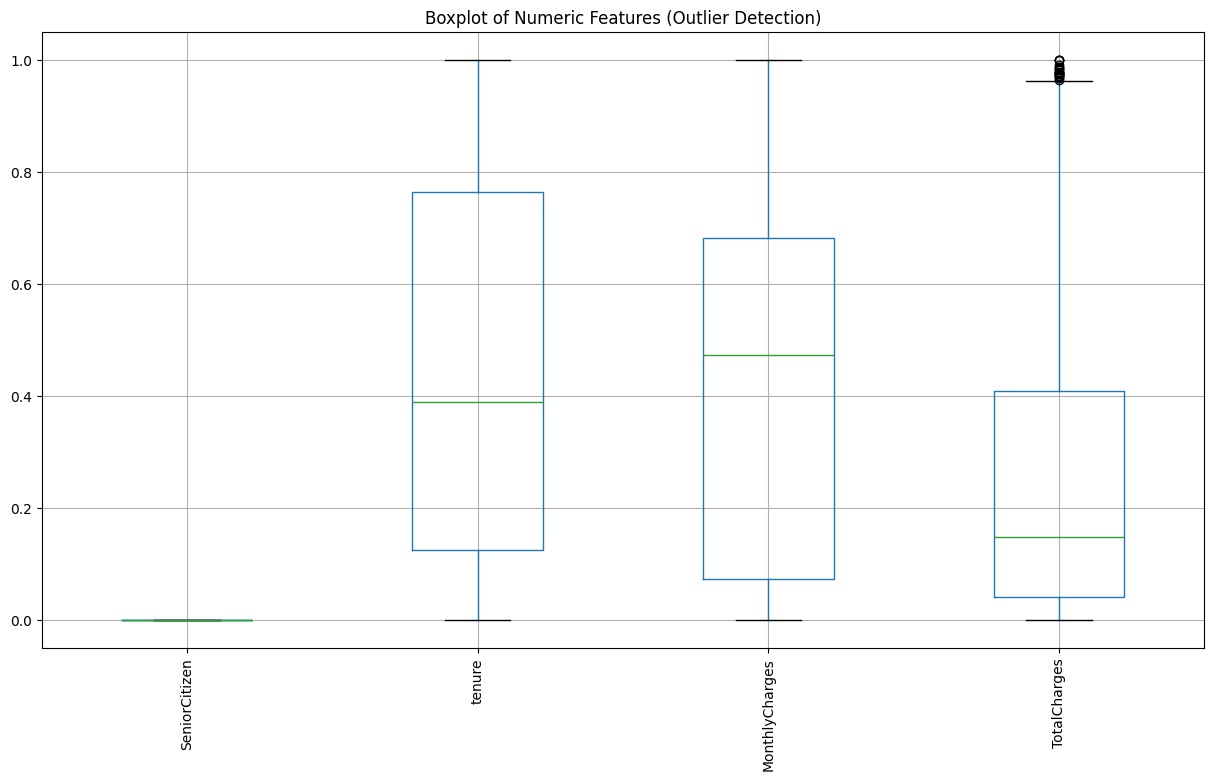

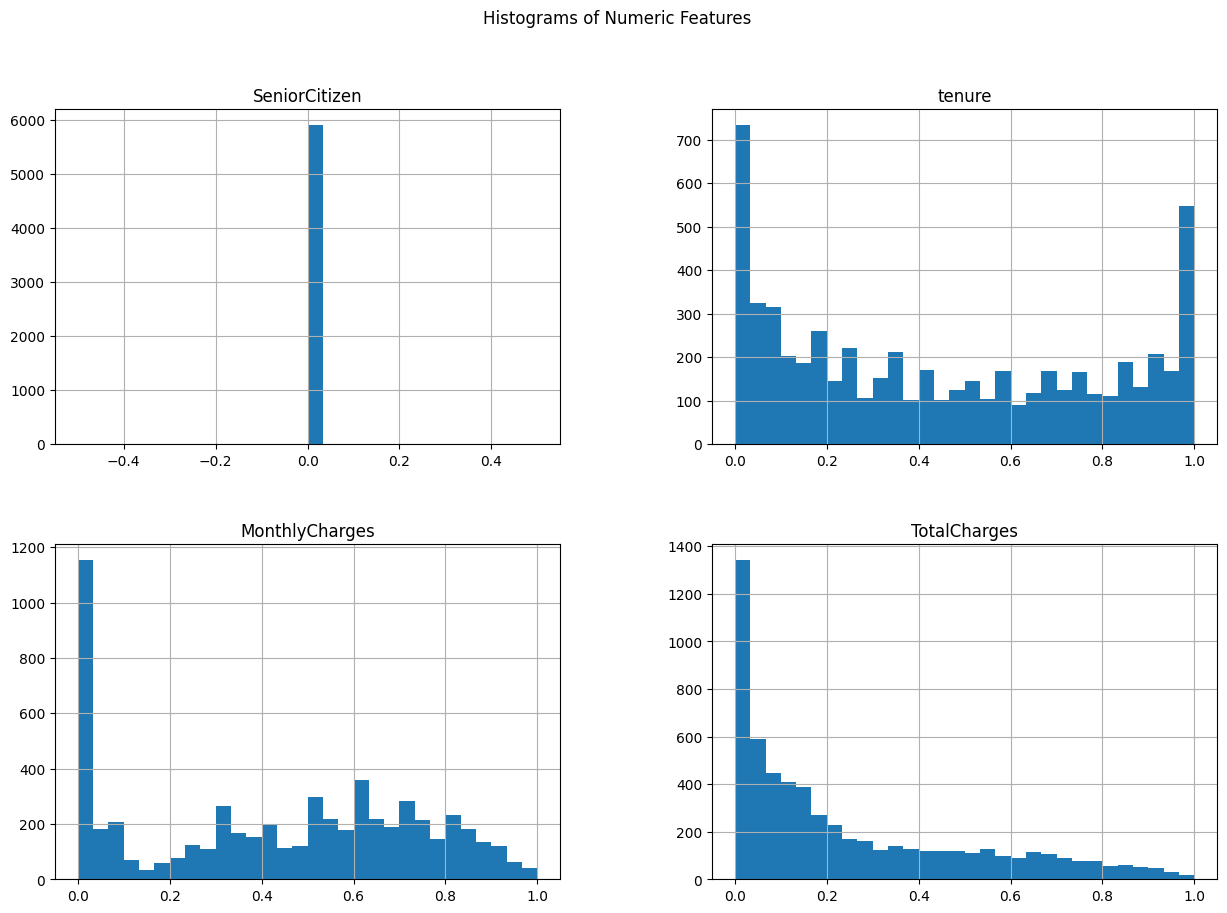

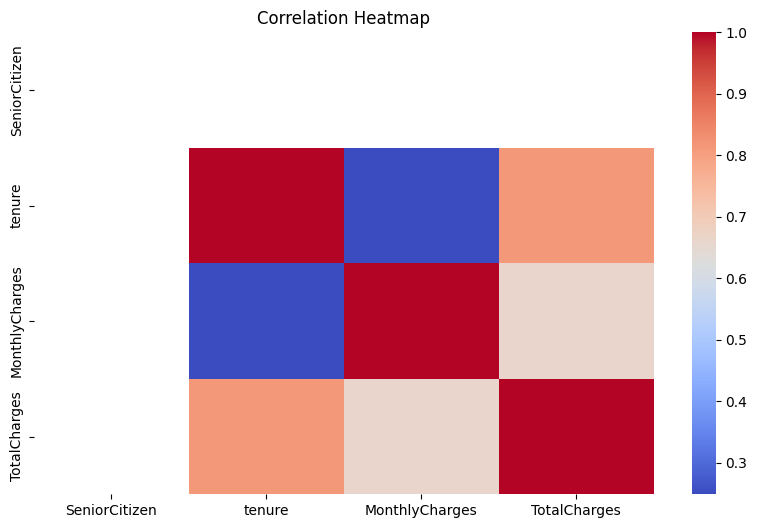

In [22]:
visualize_outliers(cleaned_df)

In [23]:
df = cleaned_df
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [24]:
# =========================
# Feature Engineering
# =========================

# --- Customer lifecycle segmentation based on tenure ---
# Categorize customers into lifecycle stages (New, Early, Mid, Loyal)
df['tenure_group'] = pd.cut(df['tenure'],
                           bins=[0, 12, 24, 48, 72],
                           labels=['New', 'Early', 'Mid', 'Loyal'])

# --- Average monthly spending approximation ---
# Avoid division by zero by adding 1 to tenure
df['avg_monthly_spend'] = df['TotalCharges'] / (df['tenure'] + 1)

# --- High-value customer indicator ---
# Identify customers with above-median monthly charges
df['high_value'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# --- Total revenue segmentation ---
# Divide customers into quartiles based on total charges
df['totalcharges_group'] = pd.qcut(df['TotalCharges'], 4, labels=['Low','Mid','High','VIP'])

# --- Contract and monthly charge interaction (categorical) ---
# Combine contract type with spending behavior
df['contract_monthly'] = df['Contract'] + "_" + df['MonthlyCharges'].astype(str)

# --- Contract and monthly charge interaction (numerical) ---
# Encode contract type and multiply by monthly charges
df['monthly_contract_interaction'] = df['MonthlyCharges'] * df['Contract'].map({
    'Month-to-month': 1,
    'One year': 2,
    'Two year': 3
})

# --- Tenure and spending interaction ---
# Capture long-term value behavior
df['tenure_charge_interaction'] = df['tenure'] * df['MonthlyCharges']

# --- Service usage features ---
# List of service-related features
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
            'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

# Count how many services each customer uses
df['num_services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# --- Technical support indicator ---
# Binary flag for having tech support
df['has_support'] = (df['TechSupport'] == 'Yes').astype(int)

# --- Security-related services ---
# Count number of security services (OnlineSecurity + OnlineBackup)
df['security_services'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int)
)

# --- Contract risk level ---
# Assign higher risk to short-term contracts
df['contract_risk'] = df['Contract'].map({
    'Month-to-month': 3,
    'One year': 2,
    'Two year': 1
})

# --- Payment behavior ---
# Identify customers using automatic payment methods
df['auto_payment'] = df['PaymentMethod'].str.contains('automatic').astype(int)

# --- Paperless billing flag ---
# Binary indicator for paperless billing usage
df['paperless_flag'] = (df['PaperlessBilling'] == 'Yes').astype(int)

# --- Demographic risk feature ---
# Identify senior customers without dependents
df['senior_alone'] = (
    (df['SeniorCitizen'] == 1) &
    (df['Dependents'] == 'No')
).astype(int)

# --- Service diversity ---
# Ratio of used services to total available services
df['service_diversity'] = df['num_services'] / len(services)

# --- Engagement score (composite feature) ---
# Weighted combination of tenure, number of services, and monthly charges
df['engagement_score'] = (
    df['tenure'] * 0.4 +
    df['num_services'] * 0.3 +
    df['MonthlyCharges'] * 0.3
)

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

# Split indices only once
X_base = df.drop('Churn', axis=1)

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    X_base.index, y, test_size=0.2, random_state=42, stratify=y
)

# Apply same split to both datasets
X_train = X.loc[X_train_idx]
X_test = X.loc[X_test_idx]


===== Logistic Regression (No SMOTE) =====
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       902
           1       0.56      0.74      0.64       279

    accuracy                           0.80      1181
   macro avg       0.73      0.78      0.75      1181
weighted avg       0.83      0.80      0.81      1181

ROC-AUC: 0.8563228667477291
PR-AUC: 0.6649828005320972

===== Decision Tree (No SMOTE) =====
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       902
           1       0.49      0.59      0.54       279

    accuracy                           0.76      1181
   macro avg       0.68      0.70      0.69      1181
weighted avg       0.78      0.76      0.77      1181

ROC-AUC: 0.7014638914717594
PR-AUC: 0.38781387373585213

===== Random Forest (No SMOTE) =====
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       902
      

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:50:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.85      0.89      0.87       902
           1       0.58      0.47      0.52       279

    accuracy                           0.79      1181
   macro avg       0.71      0.68      0.69      1181
weighted avg       0.78      0.79      0.79      1181

ROC-AUC: 0.8238462516589976
PR-AUC: 0.5908220433538035

===== Logistic Regression (With SMOTE) =====
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       902
           1       0.58      0.72      0.64       279

    accuracy                           0.81      1181
   macro avg       0.74      0.78      0.75      1181
weighted avg       0.83      0.81      0.82      1181

ROC-AUC: 0.8550751416605075
PR-AUC: 0.6570539046400867

===== Decision Tree (With SMOTE) =====
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       902
           1       0.58      0.58      0.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:51:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.87      0.91      0.89       902
           1       0.64      0.54      0.59       279

    accuracy                           0.82      1181
   macro avg       0.75      0.73      0.74      1181
weighted avg       0.81      0.82      0.82      1181

ROC-AUC: 0.8470066518847007
PR-AUC: 0.635240429278106

===== Stacking Model =====


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.85      0.94      0.89       902
           1       0.71      0.44      0.55       279

    accuracy                           0.83      1181
   macro avg       0.78      0.69      0.72      1181
weighted avg       0.81      0.83      0.81      1181

ROC-AUC: 0.8427846521866978
PR-AUC: 0.6338905640436736


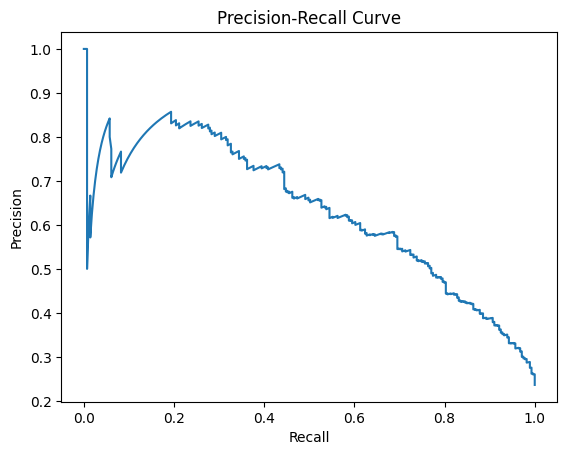

In [26]:
# =========================
# 2. Preprocessing
# =========================
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# =========================
# 3. Feature Selection
# =========================
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

feature_selector = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold='median'
)

# =========================
# 4. Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier

# =========================
# 5. Pipelines (No SMOTE)
# =========================
from sklearn.pipeline import Pipeline

models = {
    "Logistic Regression": Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selector),
        ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    
    "Decision Tree": Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selector),
        ('model', DecisionTreeClassifier(class_weight='balanced'))
    ]),
    
    "Random Forest": Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selector),
        ('model', RandomForestClassifier(class_weight='balanced', n_estimators=200))
    ]),
    
    "XGBoost": Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selector),
        ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
    ])
}

# =========================
# 6. Pipelines (With SMOTE)
# =========================
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

models_smote = {
    name: ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('feature_selection', feature_selector),
        ('model', model.named_steps['model'])
    ])
    for name, model in models.items()
}

# =========================
# 7. Stacking Ensemble
# =========================
stacking_model = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('model', StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=200)),
            ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
        ],
        final_estimator=LogisticRegression(max_iter=1000)
    ))
])

# =========================
# 8. Evaluation
# =========================
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))

# =========================
# 9. Run Models (No SMOTE)
# =========================
for name, model in models.items():
    print(f"\n===== {name} (No SMOTE) =====")
    model.fit(X_train, y_train)
    evaluate_model(model, X_test, y_test)

# =========================
# 10. Run Models (With SMOTE)
# =========================
for name, model in models_smote.items():
    print(f"\n===== {name} (With SMOTE) =====")
    model.fit(X_train, y_train)
    evaluate_model(model, X_test, y_test)

# =========================
# 11. Stacking Model
# =========================
print("\n===== Stacking Model =====")
stacking_model.fit(X_train, y_train)
evaluate_model(stacking_model, X_test, y_test)

# =========================
# 12. Precision-Recall Curve
# =========================
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = stacking_model.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [27]:
import numpy as np
import pandas as pd

# =========================
# Step 1: Get trained pipeline
# =========================
model_pipe = models["Random Forest"]
model_pipe.fit(X_train, y_train)

# =========================
# Step 2: Get preprocessing + feature selection
# =========================
preprocessor = model_pipe.named_steps['preprocessor']
selector = model_pipe.named_steps['feature_selection']
model = model_pipe.named_steps['model']

# =========================
# Step 3: Get feature names after preprocessing
# =========================
feature_names = preprocessor.get_feature_names_out()

# =========================
# Step 4: Apply feature selection mask
# =========================
mask = selector.get_support()
selected_features = np.array(feature_names)[mask]

# =========================
# Step 5: Get feature importances
# =========================
importances = model.feature_importances_

# =========================
# Step 6: Build dataframe safely
# =========================
feat_imp = pd.DataFrame({
    'feature': selected_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# =========================
# Step 7: Show top features
# =========================
print(feat_imp.head(15))

                                  feature  importance
0                             num__tenure    0.047082
5       num__monthly_contract_interaction    0.044692
2                       num__TotalCharges    0.044309
3                  num__avg_monthly_spend    0.042794
6          num__tenure_charge_interaction    0.040746
1                     num__MonthlyCharges    0.040597
14                  num__engagement_score    0.039165
10                     num__contract_risk    0.033413
2315         cat__Contract_Month-to-month    0.027207
2317               cat__Contract_Two year    0.016627
2322  cat__PaymentMethod_Electronic check    0.015985
2297               cat__OnlineSecurity_No    0.015674
2295     cat__InternetService_Fiber optic    0.014510
13                 num__service_diversity    0.013667
7                       num__num_services    0.013613


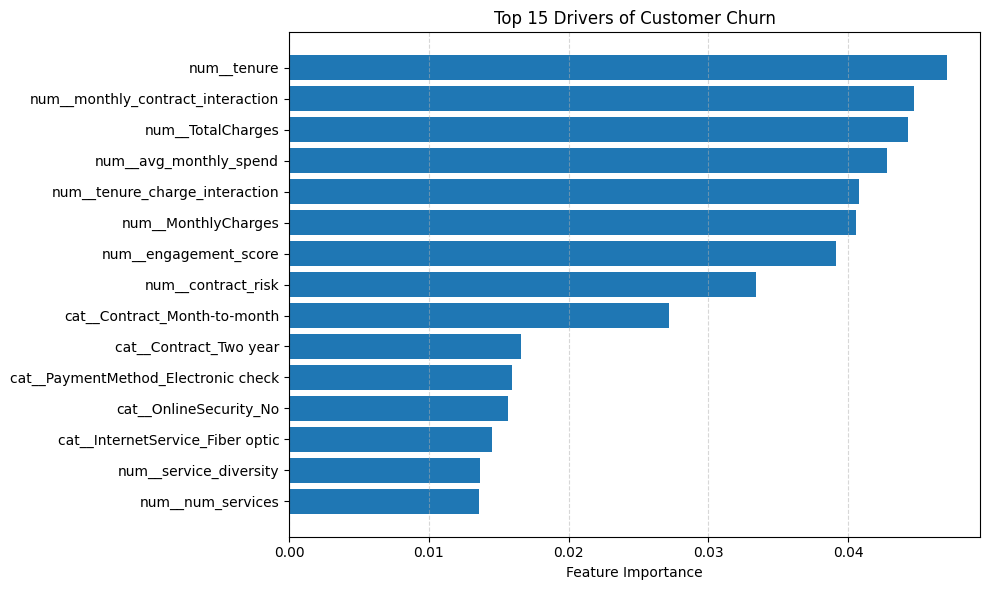

In [28]:
import matplotlib.pyplot as plt

top_feats = feat_imp.head(15)

plt.figure(figsize=(10,6))

plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1])

plt.xlabel("Feature Importance")
plt.title("Top 15 Drivers of Customer Churn")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import shap

# Train XGBoost (best for SHAP)
xgb_model = models["XGBoost"]
xgb_model.fit(X_train, y_train)

# Extract trained model after pipeline
model = xgb_model.named_steps['model']

# Transform data
X_test_transformed = xgb_model.named_steps['preprocessor'].transform(X_test)

# SHAP explainer
explainer = shap.Explainer(model)
shap_values = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)

shap.dependence_plot("num__MonthlyCharges", shap_values.values, X_test_transformed)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:53:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
